In [2]:
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import torch
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
import os
from IPython.display import display, Math

sys.path.append('../nn_model')
sys.path.append('..')
sys.path.append('../data')

sys.path.append('GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import nn_model_lib as _lib

from nn_model_lib import *


def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)


import_reload()

## Initial Setup

Specify the RUN_ID, whether you want to save the models after running the optimization. The reference values are specified in `ref_values.csv` file for each run_id. The ref values are updated after data for $s$ has been imported. 

The ref values ensure a reasonable range for the SR. The inputs $(i,d,SOC,s)$ are scaled to be between 0,1. 

In [3]:
RUN_ID = 'test4'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1.5e1)

REF_VALUES = SR_lib.get_ref_values()

UNITS, UNIT_CONV = SR_lib.get_units_dict()

LATEX_DICT = SR_lib.get_latex_dict()

VARIABLES = ['R0','R1', 'C1', 'k', 'sdot', 'Ue']
# Optimization settings for PySR
SELECTION = "best"

if os.path.exists(f'saved_sr_models/{RUN_ID}'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')


## Load the NN model and extract samples

The sample points are obtained by running the `lhs_SR.py` file and saving the values to a .csv file. 

The samples are plotted here to verify the sampling. 

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using Q0_ckpt = 17921.57581, I_ref = 24.89107751102174 and u_ref = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


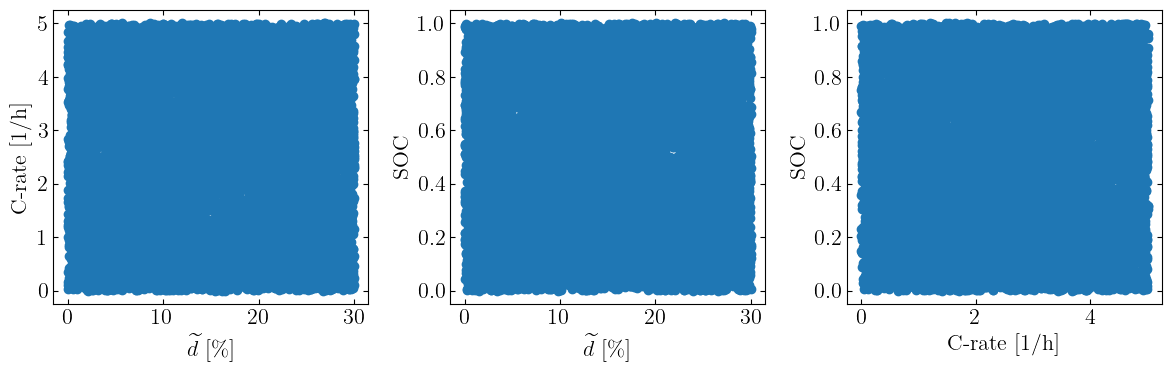

In [4]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('SR_samples.csv', usecols=['u_par', 'C_rate', 'SOC'])

s_data = pd.read_csv('../data/polished_combo/combo_half.txt', delimiter=';')

f, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[0].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[0].set_ylabel('C-rate [1/h]')
ax[1].set_xlabel('C-rate [1/h]')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[1].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[1].set_ylabel('SOC ')
ax[2].plot(df['C_rate'],df['SOC'], 'o')
ax[2].set_xlabel('C-rate [1/h]')
ax[2].set_ylabel('SOC ')
plt.tight_layout()

## Loading data for $s$



In [5]:
s_data_P = s_data[s_data['pulse'] == 1]

trajs = prepare_pulse_data(s_data_P)
s_df_p = data_param(BAT_MODEL, trajs, pulse = True)

s_data_CC = s_data[s_data['pulse'] == 0]
trajs = prepare_data(s_data_CC)
s_df_cc = data_param(BAT_MODEL, trajs, pulse = False)
s_df_tot = pd.concat([s_df_p, s_df_cc], ignore_index=True)

s_data = s_df_tot[['I', 'u_per', 'soc', 's', 'sdot']].copy()
REF_VALUES['s'] = s_data['s'].max()

s_data['C'] = s_data['I'] * 3600 / Q0


s_data['s'] = s_data['s'] / REF_VALUES['s']

s_data['C'] = s_data['C'] / REF_VALUES['C']

s_data['u_per'] = s_data['u_per'] / REF_VALUES['d']

s_data['sdot'] = s_data['sdot'] / REF_VALUES['sdot']
s_data.describe()



,I,u_per,soc,s,sdot,C
count,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000
mean,6.959620,0.429038,0.544854,0.294561,0.869936,0.279603
std,6.807070,0.309418,0.257924,0.240674,1.009850,0.273474
min,0.000000,0.000000,0.024633,0.000000,0.003351,0.000000
25%,0.000000,0.176667,0.329973,0.093446,0.087223,0.000000
50%,4.480394,0.406667,0.548750,0.227796,0.599727,0.180000
75%,10.952074,0.686667,0.762836,0.459088,1.125820,0.440000
max,24.891078,0.990000,1.000000,1.000000,5.313158,1.000000


### Save the reference value for $s$

In [6]:
# Save reference values for simulating the observed outputs. 

save_refvalues = True
if save_refvalues:
    df_ref = pd.DataFrame(REF_VALUES, index=[0])
    df_existing = pd.read_csv("saved_sr_models/ref_values.csv")
    if RUN_ID in df_existing['run_id'].values:
        print(f'Run ID {RUN_ID} already exists in ref_values.csv. Did not save new reference values.')
    else:
        df_ref.to_csv(f'saved_sr_models/ref_values_{RUN_ID}.csv', index=False)
        df_ref['run_id'] = RUN_ID
        df_new = pd.DataFrame(df_ref, columns=df_existing.columns.values)
        df_combined = pd.concat([df_existing,df_new], ignore_index=True)
        df_combined.to_csv("saved_sr_models/ref_values.csv", index=False)

        #df_combined.to_excel("exp_log/Euler_exps.xlsx", index=False)

## Defining functions for computing the elements

In [7]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def sample_element(c_rate, u_per, soc):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    return R0.item(), R1.item(), C1.item(), k.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),4+3))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        r0, r1,c1,k = sample_element(c_rate, u_per, soc)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], c_rate, u_per, soc]
    return samples


### Generating samples and displaying the df for $R_0$, $R_1$, $C_1$ and $k$

In [8]:
samples = generate_data(df.values)
VARIABLES = ['R0','R1', 'C1', 'k']
N_VAR = len(VARIABLES)
cols = VARIABLES + ['C', 'u_per', 'soc']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples
data['u_per'] =  data['u_per'] / REF_VALUES['d']
data['C'] =  data['C'] / REF_VALUES['C']
data.describe() 

100%|██████████| 10000/10000 [00:09<00:00, 1075.81it/s]


,R0,R1,C1,k,C,u_per,soc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.823645,5.678430,9.447663,2.887359,0.499987,0.499977,0.499957
std,0.149276,10.257809,3.838857,0.377416,0.288700,0.288720,0.288703
min,0.400871,0.188216,0.123883,2.239312,0.000000,0.000000,0.000000
25%,0.744825,0.592013,10.566363,2.558353,0.249950,0.250008,0.250000
50%,0.809587,0.721194,11.240972,2.840583,0.500000,0.500017,0.500000
75%,0.877739,1.949865,11.378365,3.192075,0.750000,0.749958,0.750000
max,1.482466,28.958312,13.489980,3.777907,1.000000,0.999900,1.000000


### Visual overview of the scaled values

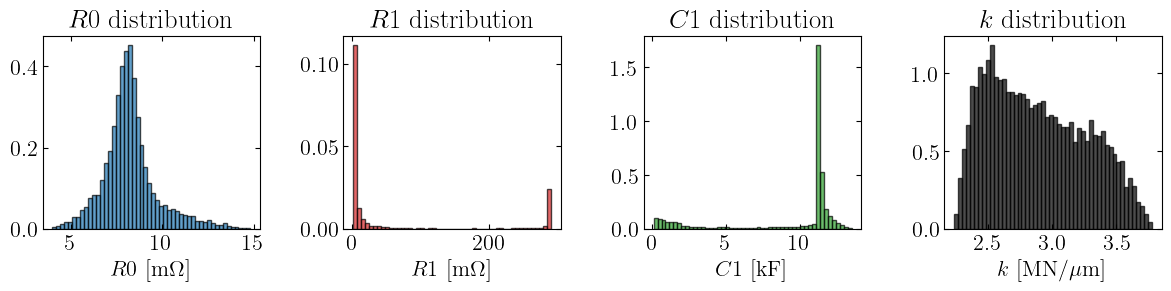

In [9]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var]*UNIT_CONV[var]*REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [10]:
def get_XY(d_frame, s_frame = None):
    '''Get input and output arrays for symbolic regression. If s_frame is provided, also return sdot values and corresponding inputs.'''

    if s_frame is not None:
        for i in range(1,10):
            inds = np.arange(0,len(s_frame)) % i == 0
            if inds.sum() < 1e4:
                break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values 
    Y_R1 = d_frame['R1'].values 
    Y_C1 = d_frame['C1'].values 
    Y_k  = d_frame['k'].values  
    if s_frame is not None:
        Y_s = s_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = s_frame[['C', 'u_per', 'soc', 's']].values
        Y_s = Y_s[inds]
        X_s = X_s[inds]
    else: 
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)
    
    return X,Y_R0, Y_R1 ,Y_C1, Y_k, Y_s, X_s

### Get training and test data 

In this case, the test data is not used. So the split is neglected. 

In [11]:
split_train = int(len(data) * 0.8)
s_split_train = int(len(s_data) * 0.8)

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = SR_lib.prepare_data(data_train)
    trajs_test  = SR_lib.prepare_data(data_test)
else:
    data_train  = data#[:split_train]
    data_test   = data#[split_train:]
    s_data_train = s_data#[:s_split_train]
    s_data_test = s_data#[s_split_train:]


X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train, s_frame = s_data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test, s_frame = s_data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    'sdot':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    'sdot':  Ys_test
}



# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_test4...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.022280982
Equation: 0.8237197

Model 1: Complexity=3, Loss=0.021061784
Equation: sqrt(sqrt(soc))

Model 2: Complexity=4, Loss=0.0149950655
Equation: soc ^ soc

Model 3: Complexity=5, Loss=0.0091173155
Equation: sqrt(cube(soc) + 0.46745774)

Model 4: Complexity=6, Loss=0.0065663774
Equation: sqrt(cube(square(soc)) + 0.55095845)

Model 5: Complexity=10, Loss=0.0047810995
Equation: sqrt((cube(soc) + (0.5027477 ^ C)) / 1.3789138)

Model 6: Complexity=12, Loss=0.0039304453
Equation: sqrt(cube(square(soc)) + ((0.6245308 ^ C) / cube(1.1402086)))

Model 7: Complexity=14, Loss=0.0033496148
Equation: sqrt(square(soc * soc) + sqrt(exp((-0.43521732 * exp(d)) - C)))

Model 8: Complexity=15, Loss=0.0030321216
Equation: sqrt(square(cube(soc) * soc) + sqrt(exp((-0.43521732 * exp(d)) - C)))

Model 9: Complexity=18, Loss=0.002988655
Equation: sqrt(sqrt(exp(exp(d) * (-0.37865463 + (square(soc * soc) - C))) + (0.28277123 * soc)))

Model 10: Complexity=20, Loss=0.0026840223
Eq

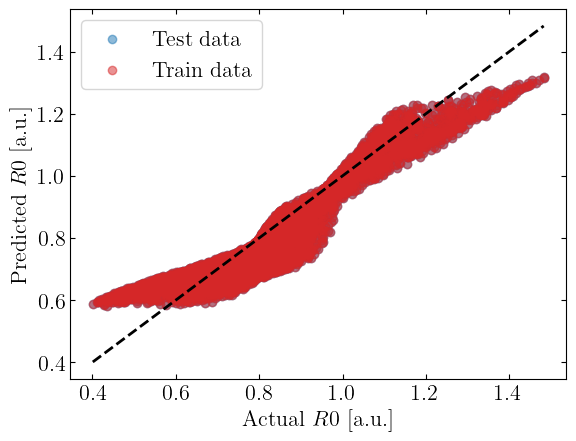

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(soc**8 + sqrt(exp(-C - 0.43521732*exp(d))))
Loss: 0.0030321216
Best model complexity: 15


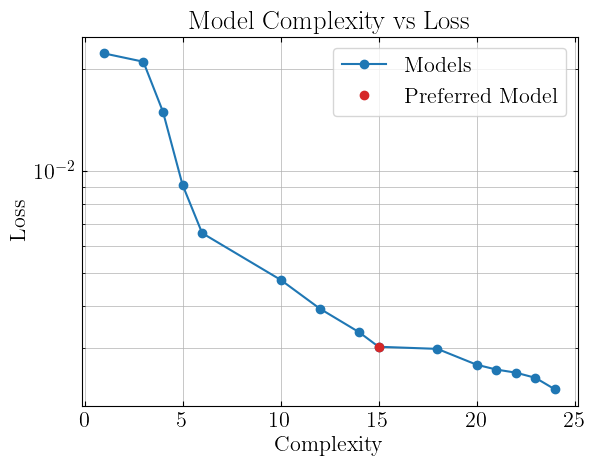

In [12]:
import_reload()
model_R0 = SR_lib.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
SR_lib.print_models(df_model_R0)
import_reload() 
SR_lib.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
SR_lib.print_best_model(model_R0)
SR_lib.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_test4...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=105.21213
Equation: 5.6772556

Model 1: Complexity=3, Loss=97.51105
Equation: C * 11.034874

Model 2: Complexity=4, Loss=87.511925
Equation: exp(2.054813 - soc)

Model 3: Complexity=5, Loss=40.78728
Equation: exp(cube(1.5172207 - soc))

Model 4: Complexity=6, Loss=37.789726
Equation: cube((0.73841536 - soc) / 0.23871307)

Model 5: Complexity=8, Loss=36.72009
Equation: exp(soc * (soc * -18.369032)) / 0.03800037

Model 6: Complexity=9, Loss=22.477352
Equation: exp(((C ^ soc) - soc) * 3.671489)

Model 7: Complexity=10, Loss=22.094234
Equation: exp((C + 3.0082388) - cube(square(soc - -0.7976326)))

Model 8: Complexity=12, Loss=9.188459
Equation: exp(3.4875963 - square((C / -0.61182564) + cube(soc - -1.0092313)))

Model 9: Complexity=14, Loss=7.373802
Equation: exp(3.505423 - square((-0.46021754 - cube(-1.1453941 - soc)) + (C / -0.534747)))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp(3.4875963 - (C/(-0.61182564) + (soc - 1*(-1.0092313))**3)**2)
Loss: 9.188459
Best model complexity: 12


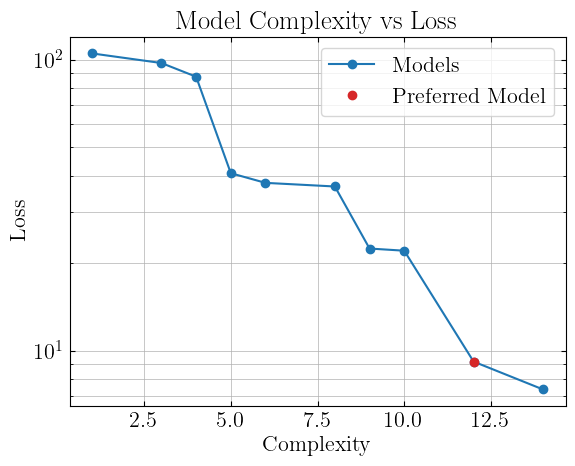

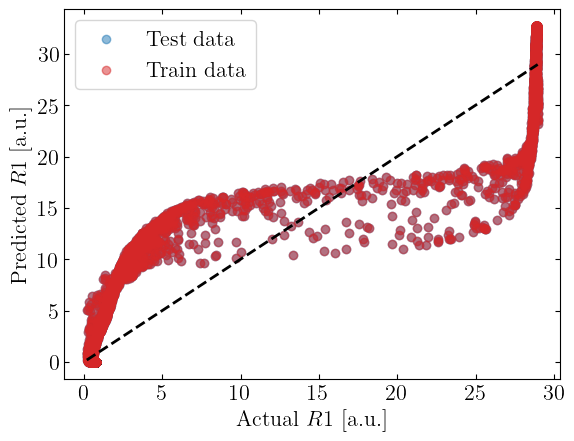

In [13]:
import_reload()
model_R1 = SR_lib.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
SR_lib.print_models(df_model_R1)
SR_lib.print_best_model(model_R1)
SR_lib.pareto_plot(model_R1)
SR_lib.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_test4...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=14.735352
Equation: 9.447221

Model 1: Complexity=3, Loss=13.298023
Equation: soc + 8.947745

Model 2: Complexity=4, Loss=5.7036915
Equation: sqrt(soc) * 13.983381

Model 3: Complexity=6, Loss=5.2811995
Equation: (soc ^ 0.4028316) * 13.540765

Model 4: Complexity=8, Loss=2.6388876
Equation: soc * (49.98449 / (4.7304196 ^ soc))

Model 5: Complexity=10, Loss=2.3978293
Equation: ((58.80077 / (5.004389 ^ soc)) * soc) - 1.2476087

Model 6: Complexity=11, Loss=2.333524
Equation: (soc * (58.80077 / (5.004389 ^ soc))) - exp(C)

Model 7: Complexity=12, Loss=2.2149742
Equation: ((-0.98292875 - (soc * -59.43901)) / (5.477358 ^ soc)) - C

Model 8: Complexity=14, Loss=2.0198126
Equation: (((-3.9840393 * C) - (-47.201603 * soc)) / (6.4676023 ^ soc)) * 1.408748

Model 9: Complexity=16, Loss=2.010342
Equation: ((((C * -3.9840393) - (soc * -47.201603)) / (6.4676023 ^ soc)) - -0.06561097) * 1.408748

Model 10: Complexity=17, Loss=1.9148238
Equation: (((((soc + (0.04185072 ^ s

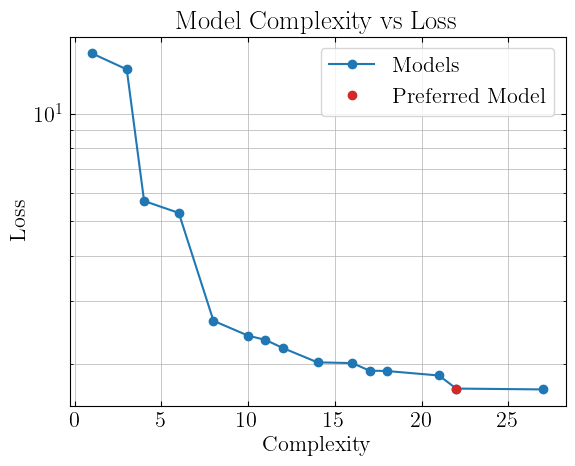

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: -C + (soc + ((0.015781375**soc + soc)*1.7924418)**(-2.0397086))**1.9806354*7.8628855 - 1*0.44486222
Loss: 1.7062786
Best model complexity: 22


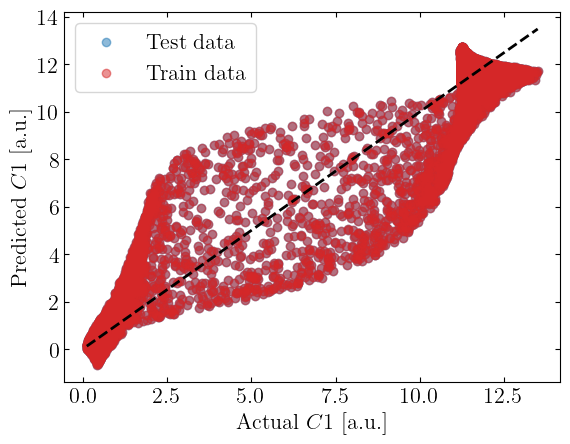

In [14]:
import_reload()
model_C1 = SR_lib.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
SR_lib.print_models(df_model_C1)
SR_lib.pareto_plot(model_C1)
SR_lib.print_best_model(model_C1)
SR_lib.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_test4...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.14242895
Equation: 2.887352

Model 1: Complexity=3, Loss=0.015178839
Equation: d + 2.3875499

Model 2: Complexity=4, Loss=0.014986319
Equation: square(d) + 2.5553107

Model 3: Complexity=5, Loss=0.009398803
Equation: (d + 1.7838393) * 1.2641494

Model 4: Complexity=6, Loss=0.008038457
Equation: exp(d + -0.27409756) + 1.5816753

Model 5: Complexity=8, Loss=0.0078338925
Equation: ((0.70131916 ^ soc) - -1.5484521) + d

Model 6: Complexity=9, Loss=0.0077256537
Equation: (d * d) + exp(exp(soc * -0.12522975))

Model 7: Complexity=11, Loss=0.0015213795
Equation: exp(-0.12830608 * soc) * (2.5394952 + square(d + 0.1804112))

Model 8: Complexity=12, Loss=0.0013059166
Equation: (square(d + 0.1804112) + exp(exp(soc * -0.13441679))) * 0.9319653

Model 9: Complexity=14, Loss=0.00028050467
Equation: sqrt(exp(sqrt((square(d - -1.566204) * (0.80238724 ^ soc)) + 0.58909667)))

Model 10: Complexity=16, Loss=0.00020785436
Equation: sqrt((0.8096523 ^ soc) * exp(sqrt(square(squ

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 1.38270035933584*0.94879407**(2*soc)*sqrt(-d + exp(sqrt((-d - 1.1485645)**2)))
Loss: 6.575354e-05
Best model complexity: 17


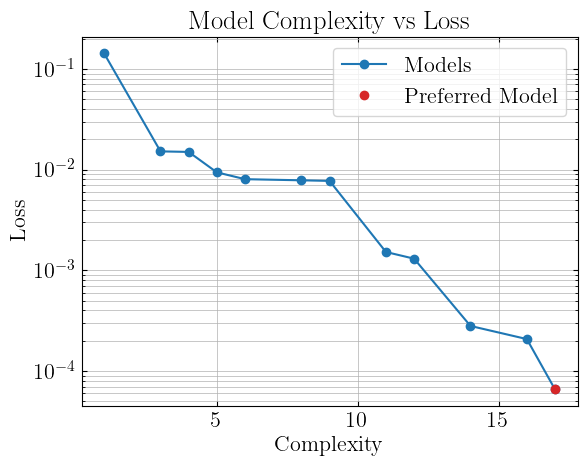

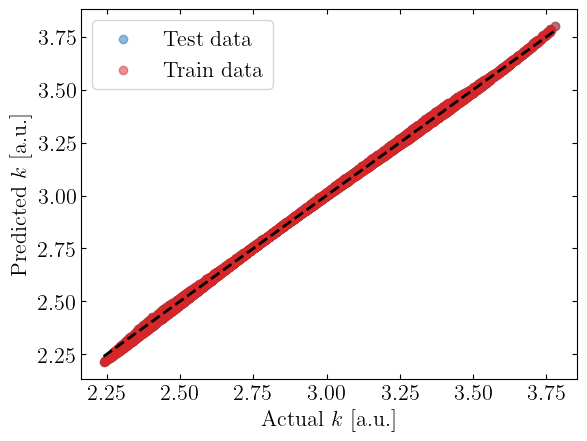

In [15]:
import_reload()
model_k = SR_lib.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
SR_lib.print_models(df_model_k)
SR_lib.print_best_model(model_k)
SR_lib.pareto_plot(model_k)
SR_lib.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(i,d,\mathrm{SOC},s)$

Variable names for element sdot: ['C', 'd', 'soc', 's']
Running symbolic regression for element sdot with run_id sdot_test4...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.0071614
Equation: C

Model 1: Complexity=2, Loss=0.7823736
Equation: exp(C)

Model 2: Complexity=3, Loss=0.3823283
Equation: C * 3.0125017

Model 3: Complexity=4, Loss=0.36027333
Equation: exp(C) - d

Model 4: Complexity=5, Loss=0.1774261
Equation: square(exp(C - d))

Model 5: Complexity=7, Loss=0.047573227
Equation: C * square(exp(0.87589073 - d))

Model 6: Complexity=8, Loss=0.0100577865
Equation: C * square(exp(0.7885936 - square(d)))

Model 7: Complexity=15, Loss=0.0073378547
Equation: (((0.5944481 + square(exp(exp(-0.17181414 - square(d))))) - d) * C) - C

Model 8: Complexity=17, Loss=0.0070095025
Equation: sqrt(square(C * ((square(exp(exp(-0.17471737 - square(d)))) - d) + -0.45505884))) - -0.029139478



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: C*(4.84131897936297*exp(-2*d**2))
Loss: 0.0100577865
Best model complexity: 8


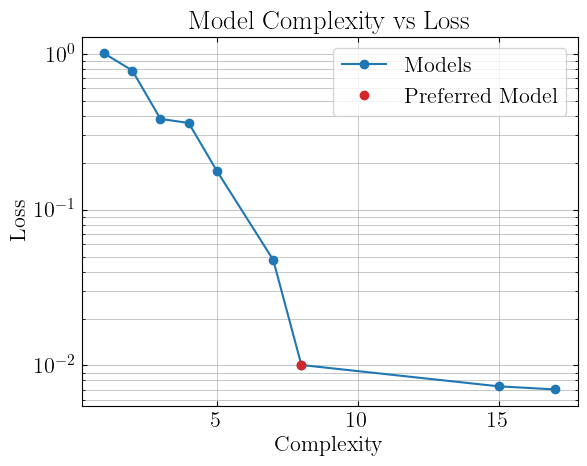

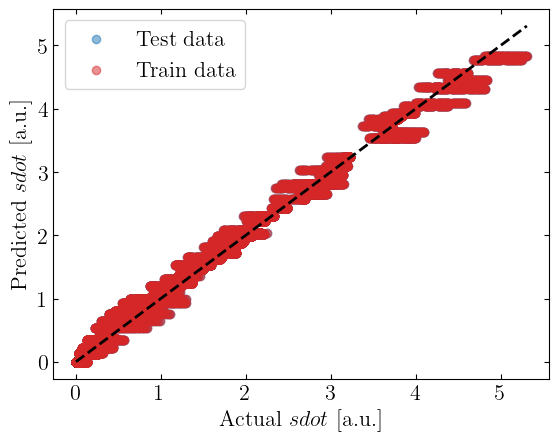

In [16]:
import_reload()
model_s = SR_lib.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f'sdot_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'sdot')
df_model_s = model_s.equations_
SR_lib.print_models(df_model_s)
SR_lib.print_best_model(model_s, s = True)
SR_lib.pareto_plot(model_s)
SR_lib.parity_plot('sdot',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

## Save the models

In [17]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    'sdot':  model_s
}

In [18]:
if SAVE:
    SR_lib.save_expressions(df_model_R0, f'R0_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_s, f'sdot_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_s.get_best(), f'sdot_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_k,  f'k_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_R1, f'R1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_C1, f'C1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}', run_id = RUN_ID)